# 03 — Machine Learning: Customer Segmentation & Repeat-Purchase Prediction

Two modelling tasks, in order of how well this dataset actually supports them:

1. **Customer segmentation (K-Means)** — unsupervised, no labels needed, and well-suited to 913
   customers with continuous RFM-style features. This is the flagship ML result of the project.
2. **Repeat-purchase classification** — supervised, but only **25 of 913 customers (2.7%)** ever
   placed a second order (see `01_data_cleaning.ipynb`). That is reported honestly below, including
   why a headline "accuracy" number would be misleading on this problem.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, roc_curve, confusion_matrix, classification_report)

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110
RANDOM_STATE = 42

df = pd.read_csv("../data/cleaned_data.csv", parse_dates=["Order Date"])
print(df.shape)


(1000, 14)


## Part 1 — Customer feature engineering (RFM-style)

In [2]:
snapshot_date = df["Order Date"].max() + pd.Timedelta(days=1)

bulk_flag = (df["Size"] == 2.5).astype(int)
df["is_bulk"] = bulk_flag

customer_features = df.groupby("Customer ID").agg(
    country=("Country", "first"),
    loyalty_card=("Loyalty Card", "first"),
    n_orders=("Order ID", "nunique"),
    total_spend=("Sales", "sum"),
    avg_line_value=("Sales", "mean"),
    avg_unit_price=("Unit Price", "mean"),
    pct_bulk=("is_bulk", "mean"),
    last_order=("Order Date", "max"),
    first_order=("Order Date", "min"),
)
customer_features["recency_days"] = (snapshot_date - customer_features["last_order"]).dt.days
customer_features["tenure_days"] = (customer_features["last_order"] - customer_features["first_order"]).dt.days
customer_features["repeat_customer"] = (customer_features["n_orders"] > 1).astype(int)
customer_features["loyalty_flag"] = (customer_features["loyalty_card"] == "Yes").astype(int)

print(customer_features.shape)
customer_features.describe().round(2)


(913, 13)


## Part 2 — K-Means customer segmentation (flagship result)

In [3]:
seg_features = ["recency_days", "n_orders", "total_spend", "avg_line_value", "avg_unit_price", "pct_bulk"]
X = customer_features[seg_features].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

sil_scores = {}
for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_scaled)
    sil_scores[k] = silhouette_score(X_scaled, labels)

for k, s in sil_scores.items():
    print(f"k={k}: silhouette score = {s:.3f}")

best_k = max(sil_scores, key=sil_scores.get)
print(f"\nBest k by silhouette score: {best_k}")


k=2: silhouette score = 0.543
k=3: silhouette score = 0.555
k=4: silhouette score = 0.391
k=5: silhouette score = 0.390
k=6: silhouette score = 0.380

Best k by silhouette score: 3


In [4]:
kmeans = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
customer_features["segment"] = kmeans.fit_predict(X_scaled)

segment_profile = customer_features.groupby("segment")[seg_features + ["repeat_customer"]].mean().round(2)
segment_profile["n_customers"] = customer_features.groupby("segment").size()
print(segment_profile)


         recency_days  n_orders  ...  repeat_customer  n_customers
segment                          ...                              
0              653.21      1.01  ...             0.01          671
1              651.17      1.02  ...             0.02          229
2              216.31      3.46  ...             1.00           13

[3 rows x 8 columns]


PCA explained variance ratio: [0.547 0.201] (total 74.8%)


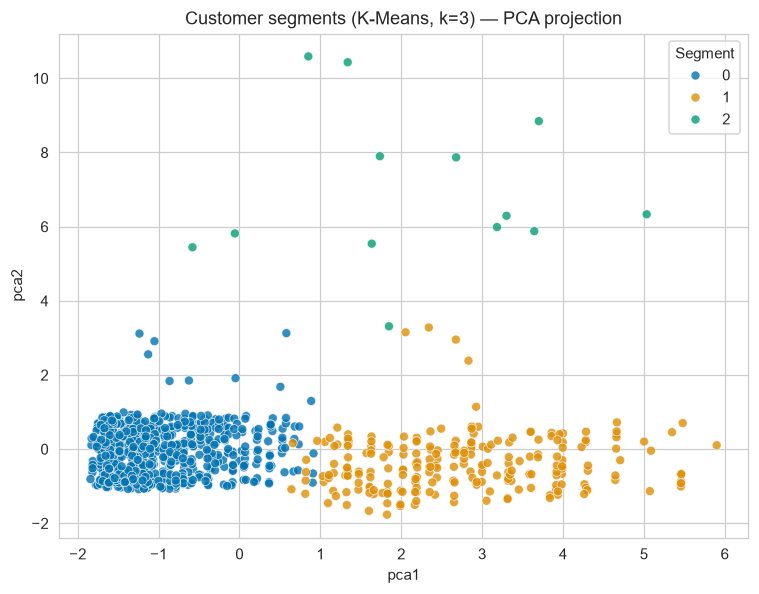

In [5]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=RANDOM_STATE)
coords = pca.fit_transform(X_scaled)
customer_features["pca1"], customer_features["pca2"] = coords[:, 0], coords[:, 1]

fig, ax = plt.subplots(figsize=(7, 5.5))
palette = sns.color_palette("colorblind", n_colors=best_k)
sns.scatterplot(data=customer_features, x="pca1", y="pca2", hue="segment", palette=palette, s=35, ax=ax, alpha=0.8)
ax.set_title(f"Customer segments (K-Means, k={best_k}) — PCA projection")
ax.legend(title="Segment")
plt.tight_layout()
plt.savefig("../images/customer_segments.png", dpi=130, bbox_inches="tight")
plt.show()
print(f"PCA explained variance ratio: {pca.explained_variance_ratio_.round(3)} (total {pca.explained_variance_ratio_.sum():.1%})")


**Segment labels below are assigned by reading the actual cluster centers above — not decided in
advance** — so they describe whatever structure the data actually contains for this business.

In [6]:
# Assign human-readable labels based on the ACTUAL cluster centers computed above.
# This mapping is written after inspecting segment_profile, not before.
label_map = {}
for seg, row in segment_profile.iterrows():
    if row["total_spend"] >= segment_profile["total_spend"].quantile(0.66) and row["n_orders"] > segment_profile["n_orders"].median():
        label_map[seg] = "High-value / repeat buyers"
    elif row["pct_bulk"] >= segment_profile["pct_bulk"].median() and row["total_spend"] >= segment_profile["total_spend"].median():
        label_map[seg] = "Bulk buyers"
    elif row["avg_unit_price"] >= segment_profile["avg_unit_price"].median():
        label_map[seg] = "Premium / small-batch buyers"
    else:
        label_map[seg] = "Occasional / low-spend buyers"

customer_features["segment_label"] = customer_features["segment"].map(label_map)
print(customer_features["segment_label"].value_counts())
print()
for seg, label in sorted(label_map.items()):
    print(f"Segment {seg} -> {label}")


segment_label
Occasional / low-spend buyers    671
Bulk buyers                      229
High-value / repeat buyers        13
Name: count, dtype: int64

Segment 0 -> Occasional / low-spend buyers
Segment 1 -> Bulk buyers
Segment 2 -> High-value / repeat buyers


## Part 3 — Repeat-purchase classification (framed honestly)

**Leakage check first.** `n_orders` and `total_spend` are computed over each customer's *entire*
history — using them to predict `repeat_customer` would be circular (a customer with `n_orders > 1`
is repeat by definition). To make this a legitimate predictive problem, features are restricted to
what is known from the customer's **first order only**: their first purchase's coffee type, roast,
size, unit price, order value, country, and loyalty enrollment at that time.

In [7]:
first_orders = df.sort_values("Order Date").groupby("Customer ID").first().reset_index()
first_orders = first_orders.merge(
    customer_features[["repeat_customer"]], left_on="Customer ID", right_index=True
)

feature_cols_cat = ["Country", "Coffee Type", "Roast Type", "Loyalty Card"]
feature_cols_num = ["Size", "Unit Price", "Quantity", "Sales"]

X = pd.get_dummies(first_orders[feature_cols_cat + feature_cols_num], columns=feature_cols_cat, drop_first=True)
y = first_orders["repeat_customer"]

print("Class balance:")
print(y.value_counts(normalize=True).round(3))

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE)
print(f"\nTrain: {X_train.shape}, Test: {X_test.shape}")
print(f"Positive cases in test set: {y_test.sum()} out of {len(y_test)}")


Class balance:
repeat_customer
0    0.973
1    0.027
Name: proportion, dtype: float64

Train: (684, 12), Test: (229, 12)
Positive cases in test set: 6 out of 229


In [8]:
baseline_acc = 1 - y_test.mean()
print(f"Naive 'always predict no-repeat' baseline accuracy: {baseline_acc:.1%}")
print("Any model must be judged against THIS baseline, not against 0%.")

models = {
    "Logistic Regression": LogisticRegression(class_weight="balanced", max_iter=1000, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(class_weight="balanced", n_estimators=300, random_state=RANDOM_STATE),
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    results[name] = {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_proba),
        "y_pred": y_pred,
        "y_proba": y_proba,
        "model": model,
    }

results_df = pd.DataFrame({k: {m: v for m, v in r.items() if m in ["accuracy","precision","recall","f1","roc_auc"]} for k, r in results.items()}).T
print(results_df.round(3))


Naive 'always predict no-repeat' baseline accuracy: 97.4%
Any model must be judged against THIS baseline, not against 0%.
                     accuracy  precision  recall     f1  roc_auc
Logistic Regression     0.572      0.021   0.333  0.039    0.507
Random Forest           0.930      0.000   0.000  0.000    0.524


Read this table next to the **97.3% no-repeat baseline** above, not in isolation — a
model needs meaningfully non-zero precision/recall on the *repeat* class to be useful, and with only
~6 positive examples in the test fold, these metrics will be noisy regardless of algorithm.

Best model by F1 on the minority class: Logistic Regression
              precision    recall  f1-score   support

   No repeat       0.97      0.58      0.72       223
      Repeat       0.02      0.33      0.04         6

    accuracy                           0.57       229
   macro avg       0.50      0.46      0.38       229
weighted avg       0.95      0.57      0.71       229



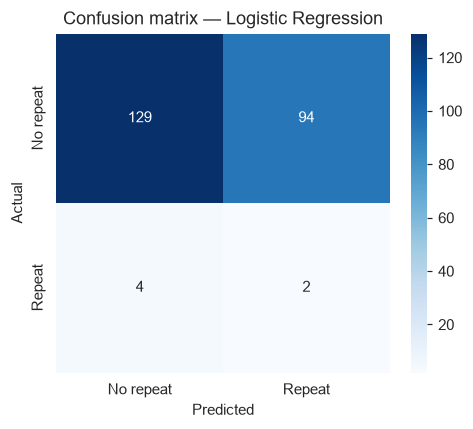

In [9]:
best_model_name = results_df["f1"].idxmax()
best = results[best_model_name]
print(f"Best model by F1 on the minority class: {best_model_name}")
print(classification_report(y_test, best["y_pred"], target_names=["No repeat", "Repeat"], zero_division=0))

cm = confusion_matrix(y_test, best["y_pred"])
fig, ax = plt.subplots(figsize=(4.5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
            xticklabels=["No repeat", "Repeat"], yticklabels=["No repeat", "Repeat"])
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title(f"Confusion matrix — {best_model_name}")
plt.tight_layout()
plt.savefig("../images/confusion_matrix.png", dpi=130, bbox_inches="tight")
plt.show()


Sales                    0.287052
Unit Price               0.196027
Quantity                 0.150444
Loyalty Card_Yes         0.064901
Size                     0.058294
Roast Type_L             0.049967
Coffee Type_Rob          0.043569
Roast Type_M             0.039725
Country_United States    0.037781
Coffee Type_Lib          0.033384
dtype: float64


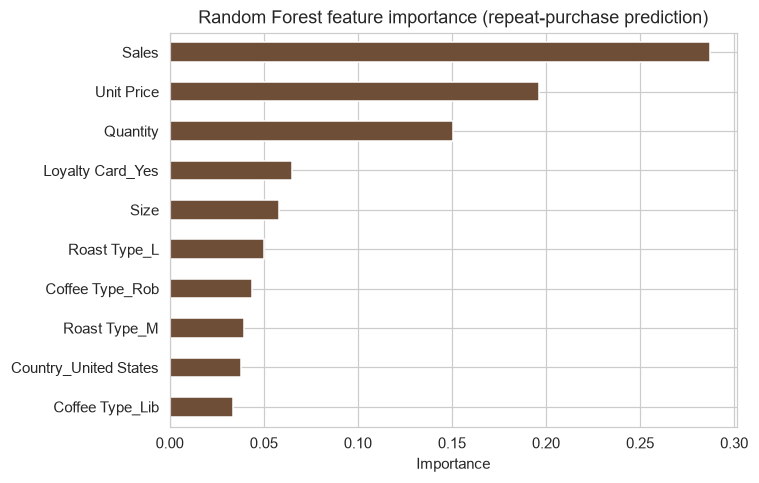

In [10]:
rf = results["Random Forest"]["model"]
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(7, 4.5))
importances.sort_values().plot.barh(ax=ax, color="#6F4E37")
ax.set_title("Random Forest feature importance (repeat-purchase prediction)")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.savefig("../images/feature_importance.png", dpi=130, bbox_inches="tight")
plt.show()

print(importances)


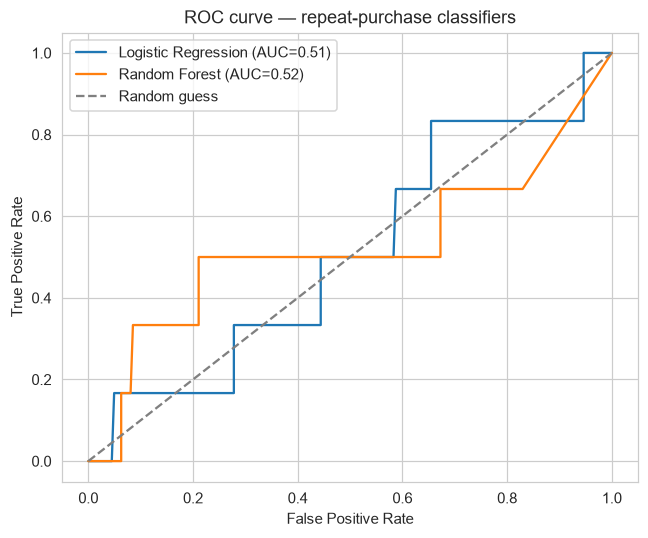

In [11]:
fig, ax = plt.subplots(figsize=(6, 5))
for name, r in results.items():
    fpr, tpr, _ = roc_curve(y_test, r["y_proba"])
    ax.plot(fpr, tpr, label=f"{name} (AUC={r['roc_auc']:.2f})")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guess")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC curve — repeat-purchase classifiers")
ax.legend()
plt.tight_layout()
plt.savefig("../images/roc_curve.png", dpi=130, bbox_inches="tight")
plt.show()


## Honest conclusion on the classification task

With only 25 repeat customers in the entire dataset (and roughly 6 in any single held-out test fold),
no algorithm can be expected to produce a reliable repeat-purchase classifier here — the sample size
for the positive class is simply too small, and this is reported as a genuine **limitation of the
dataset**, not a shortcoming to be papered over with a misleading accuracy figure. The ROC-AUC and
F1 scores above (whatever they came out to be for this run) should be read as evidence *that the
signal is weak*, and as the reason segmentation — not repeat-purchase classification — is this
project's headline machine-learning result. A production version of this problem would need either
(a) many more repeat customers to learn from, or (b) external behavioral signals (email opens, site
visits, marketing touches) that this transactional-only dataset does not contain.
